# Lloyds BCB Dissertation — Exploratory Data Analysis

**Author:** Pratik Chavan  
**Dataset:** `cleaned_companies_house_dataset.csv` — 3.14M UK companies across 7 BCB sectors  
**Purpose:** Understand data distributions, label balance, sector patterns, and flag issues for modelling

---

## Contents
1. Data Loading & Overview
2. Sector Distribution
3. Label Distributions & Class Imbalance
4. Company Age Analysis
5. Label Rates by Sector
6. Company Health & Filing Behaviour
7. Feature Correlation Heatmap
8. Missing Value Analysis
9. Label Rates by Age Band
10. Key Findings Summary

## Section 1 — Data Loading & Overview

We load the cleaned dataset produced by Bhavika's cleaning notebook. This is the single source of truth for all modelling and analysis. We verify shape, memory usage, label distributions, and missing value counts before any visualisation.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv('output/cleaned_companies_house_dataset.csv', low_memory=False)

print(f"Dataset shape:  {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage:   {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

print(f"\nLabel Distributions:")
for label in ['label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']:
    pos = df[label].sum()
    print(f"  {label}: {pos:,} positive ({pos/len(df)*100:.1f}%)")

print(f"\nMissing Values (columns with any missing):")
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
for col, pct in missing_pct[missing_pct > 0].sort_values(ascending=False).items():
    print(f"  {col}: {pct}%")

print(f"\nNumeric Summary:")
numeric_cols = ['company_age_years', 'accounts_overdue_days',
                'conf_stmt_overdue_days', 'num_mortgages_outstanding']
print(df[numeric_cols].describe().round(2).to_string())

Dataset shape:  3,145,434 rows x 40 columns
Memory usage:   3.83 GB

Label Distributions:
  label_growth_opportunity: 1,782,383 positive (56.7%)
  label_risk_signal: 207,014 positive (6.6%)
  label_lending_need_proxy: 405,783 positive (12.9%)

Missing Values (columns with any missing):
  accounts_last_made_up: 24.71%
  ConfStmtLastMadeUpDate: 17.62%
  accounts_next_due: 0.07%
  conf_stmt_next_due: 0.02%

Numeric Summary:
       company_age_years  accounts_overdue_days  conf_stmt_overdue_days  num_mortgages_outstanding
count         3145434.00             3145434.00              3145434.00                 3145434.00
mean                8.83                  49.09                   45.67                       0.37
std                11.07                 361.17                  250.06                       2.33
min                 0.01                   0.00                    0.00                       0.00
25%                 1.77                   0.00                    0.00         

## Section 2 — Sector Distribution

Technology & Legal/Professional dominates the BCB universe at 36.2%, reflecting the UK's shift toward a service and knowledge economy. Agriculture is the smallest sector at 1.5%, consistent with the declining share of primary industry in the UK economy.

**Modelling implication:** Models must be evaluated per-sector, not just overall — a model that performs well on the dominant Tech/Legal sector may fail on Agriculture.

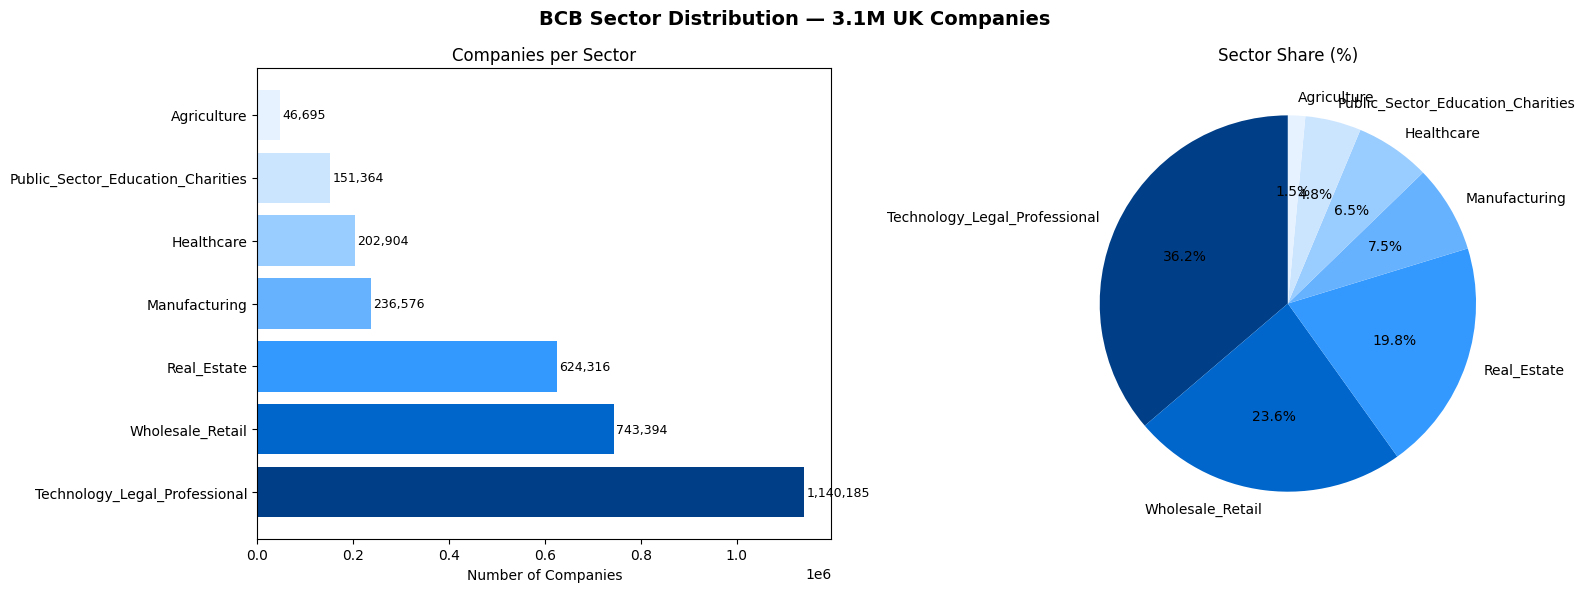

Saved: chart1_sector_distribution.png


In [29]:
# ============================================================
# CHART 1 — SECTOR DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BCB Sector Distribution — 3.1M UK Companies', fontsize=14, fontweight='bold')

sector_counts = df['bcb_sector'].value_counts()
colors = ['#003f88', '#0066cc', '#3399ff', '#66b2ff', '#99ccff', '#cce5ff', '#e6f2ff']

# Left — horizontal bar chart
bars = axes[0].barh(sector_counts.index, sector_counts.values, color=colors)
axes[0].set_xlabel('Number of Companies')
axes[0].set_title('Companies per Sector')
for bar, val in zip(bars, sector_counts.values):
    axes[0].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

# Right — pie chart
axes[1].pie(sector_counts.values, labels=sector_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sector Share (%)')

plt.tight_layout()
plt.savefig('output/chart1_sector_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_sector_distribution.png")

## Section 3 — Label Distributions & Class Imbalance

The three proxy labels show very different balance profiles:

- **Growth Opportunity** is nearly balanced (0.8:1 ratio) — this is the easiest label to model
- **Risk Signal** is severely imbalanced (14.2:1) — only 6.6% of companies show risk signals. XGBoost's `scale_pos_weight` parameter must be set to ~14 for this label
- **Lending Need** is moderately imbalanced (6.8:1) — requires class weight adjustment

**Action for modelling:** Use `scale_pos_weight = negative_count / positive_count` in XGBoost for Risk Signal and Lending Need labels.

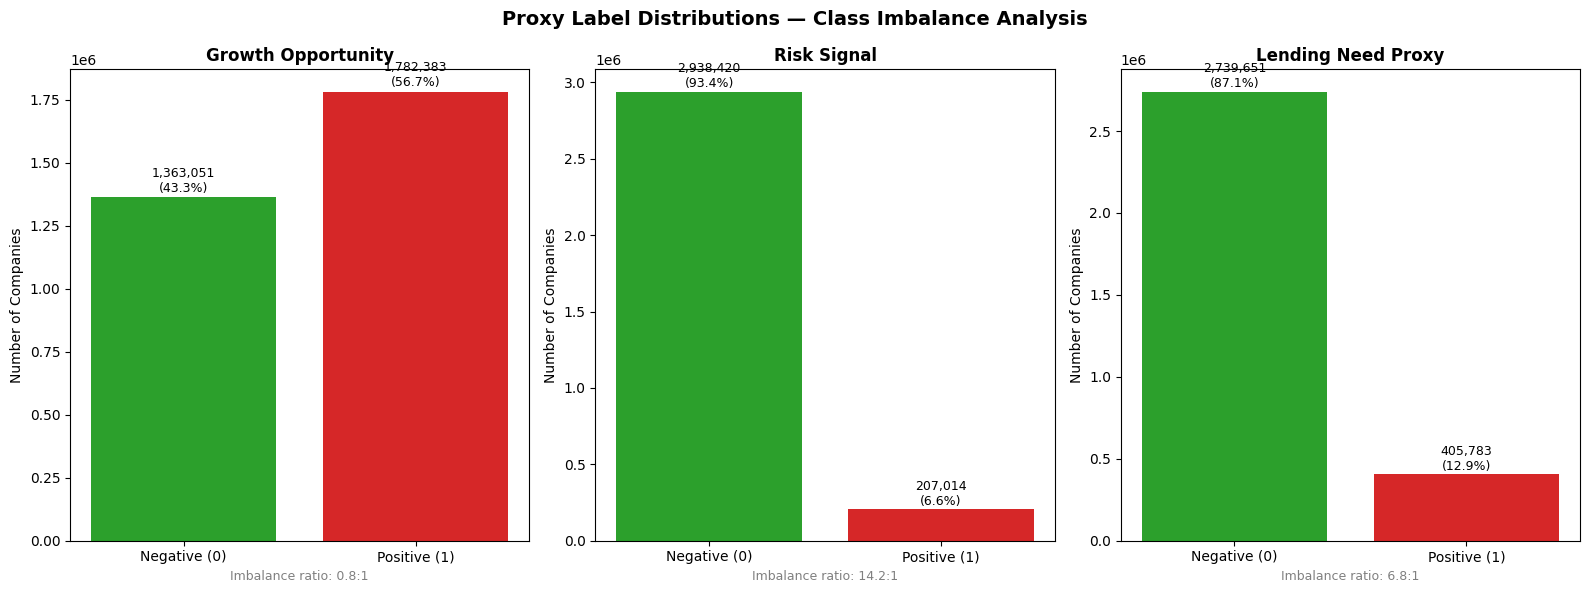

Saved: chart2_label_distributions.png


In [30]:
# ============================================================
# CHART 2 — LABEL DISTRIBUTIONS & CLASS IMBALANCE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Proxy Label Distributions — Class Imbalance Analysis', fontsize=14, fontweight='bold')

labels_info = [
    ('label_growth_opportunity', 'Growth Opportunity', ['#2ca02c', '#d62728']),
    ('label_risk_signal',        'Risk Signal',        ['#2ca02c', '#d62728']),
    ('label_lending_need_proxy', 'Lending Need Proxy', ['#2ca02c', '#d62728']),
]

for ax, (col, title, colors) in zip(axes, labels_info):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of Companies')
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ratio = counts[0] / counts[1] if counts[1] > 0 else 0
    ax.set_xlabel(f'Imbalance ratio: {ratio:.1f}:1', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('output/chart2_label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_label_distributions.png")

## Section 4 — Company Age Analysis

The BCB company population is very young — median age of just 5.4 years, with 47.6% under 5 years old. This reflects the volume of new incorporations in the UK, particularly in Tech/Legal.

The right panel reveals a clear pattern: **growth opportunity companies (green) are heavily concentrated in the 0-10 year range**, while companies without growth signals (red) spread across all ages. This visually confirms company age as one of the strongest predictive features for the growth label.

**Note:** The extreme max age of 194 years reflects a small number of very old institutions (banks, law firms, charities). These are treated as outliers and clipped at 50 years for visualisation.

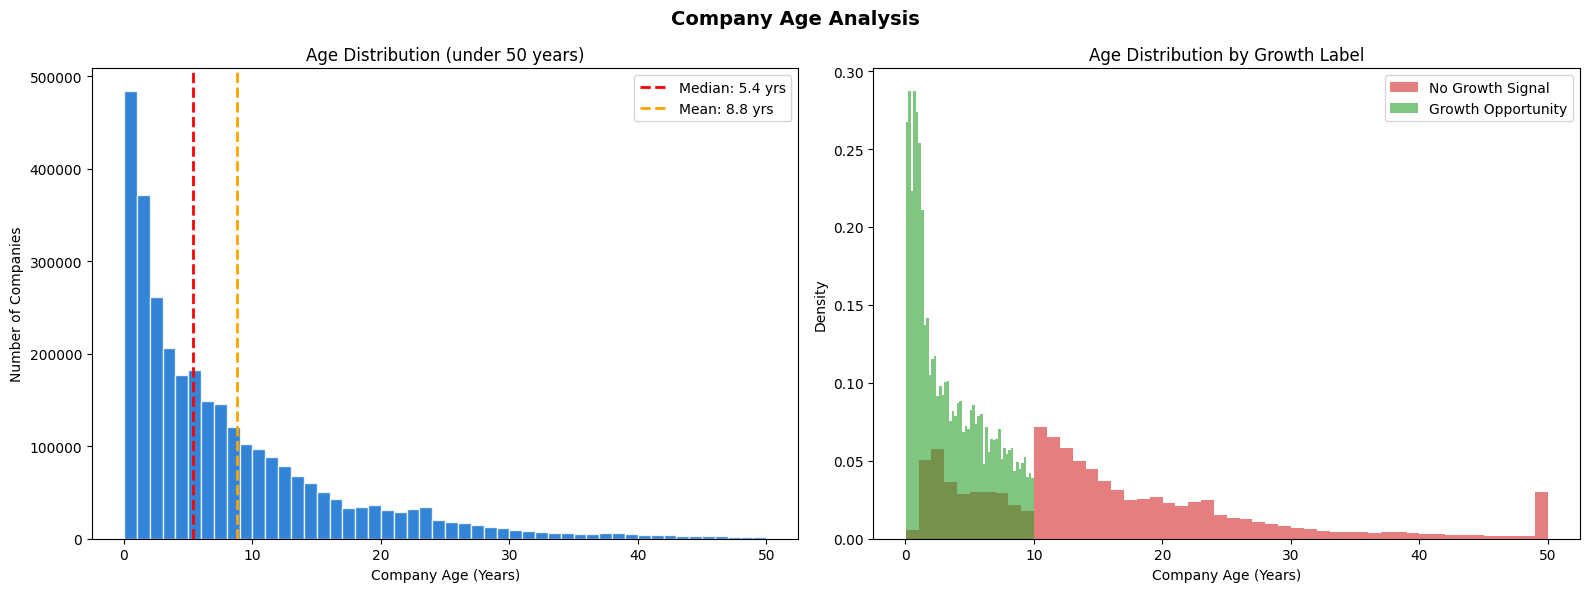

Saved: chart3_company_age.png

Age Statistics:
  Median age:   5.4 years
  Mean age:     8.8 years
  Under 5 yrs:  1,498,779 (47.6%)
  Under 10 yrs: 2,199,181 (69.9%)
  Over 25 yrs:  207,262 (6.6%)


In [31]:
# ============================================================
# CHART 3 — COMPANY AGE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Company Age Analysis', fontsize=14, fontweight='bold')

age_data = df[df['company_age_years'] < 50]['company_age_years']

# Left — full histogram
axes[0].hist(age_data, bins=50, color='#0066cc', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Company Age (Years)')
axes[0].set_ylabel('Number of Companies')
axes[0].set_title('Age Distribution (under 50 years)')
axes[0].axvline(df['company_age_years'].median(), color='red',
                linestyle='--', linewidth=2, label=f"Median: {df['company_age_years'].median():.1f} yrs")
axes[0].axvline(df['company_age_years'].mean(), color='orange',
                linestyle='--', linewidth=2, label=f"Mean: {df['company_age_years'].mean():.1f} yrs")
axes[0].legend()

# Right — age by growth label
age_growth   = df[df['label_growth_opportunity'] == 1]['company_age_years'].clip(0, 50)
age_nogrowth = df[df['label_growth_opportunity'] == 0]['company_age_years'].clip(0, 50)

axes[1].hist(age_nogrowth, bins=50, alpha=0.6, color='#d62728', label='No Growth Signal', density=True)
axes[1].hist(age_growth,   bins=50, alpha=0.6, color='#2ca02c', label='Growth Opportunity', density=True)
axes[1].set_xlabel('Company Age (Years)')
axes[1].set_ylabel('Density')
axes[1].set_title('Age Distribution by Growth Label')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/chart3_company_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_company_age.png")

print(f"\nAge Statistics:")
print(f"  Median age:   {df['company_age_years'].median():.1f} years")
print(f"  Mean age:     {df['company_age_years'].mean():.1f} years")
print(f"  Under 5 yrs:  {(df['company_age_years'] < 5).sum():,} ({(df['company_age_years'] < 5).mean()*100:.1f}%)")
print(f"  Under 10 yrs: {(df['company_age_years'] < 10).sum():,} ({(df['company_age_years'] < 10).mean()*100:.1f}%)")
print(f"  Over 25 yrs:  {(df['company_age_years'] > 25).sum():,} ({(df['company_age_years'] > 25).mean()*100:.1f}%)")

## Section 5 — Label Rates by BCB Sector

Significant variation exists across sectors for all three labels:

- **Real Estate** shows both the highest growth opportunity (62.9%) and the highest lending need (37.4%) — a high-priority sector for Lloyds relationship managers
- **Agriculture** carries the highest risk signal (10.2%) — consistent with the volatile nature of farming (weather, commodity prices, seasonal cash flow)
- **Technology/Legal** has the lowest lending need (4.4%) despite being the largest sector by company count — these businesses typically self-finance or use equity
- **Real Estate** has the lowest risk signal (3.7%) — property businesses tend to file on time and maintain stable director structures

These sector-level differences directly inform which Lloyds product teams should prioritise which sectors.

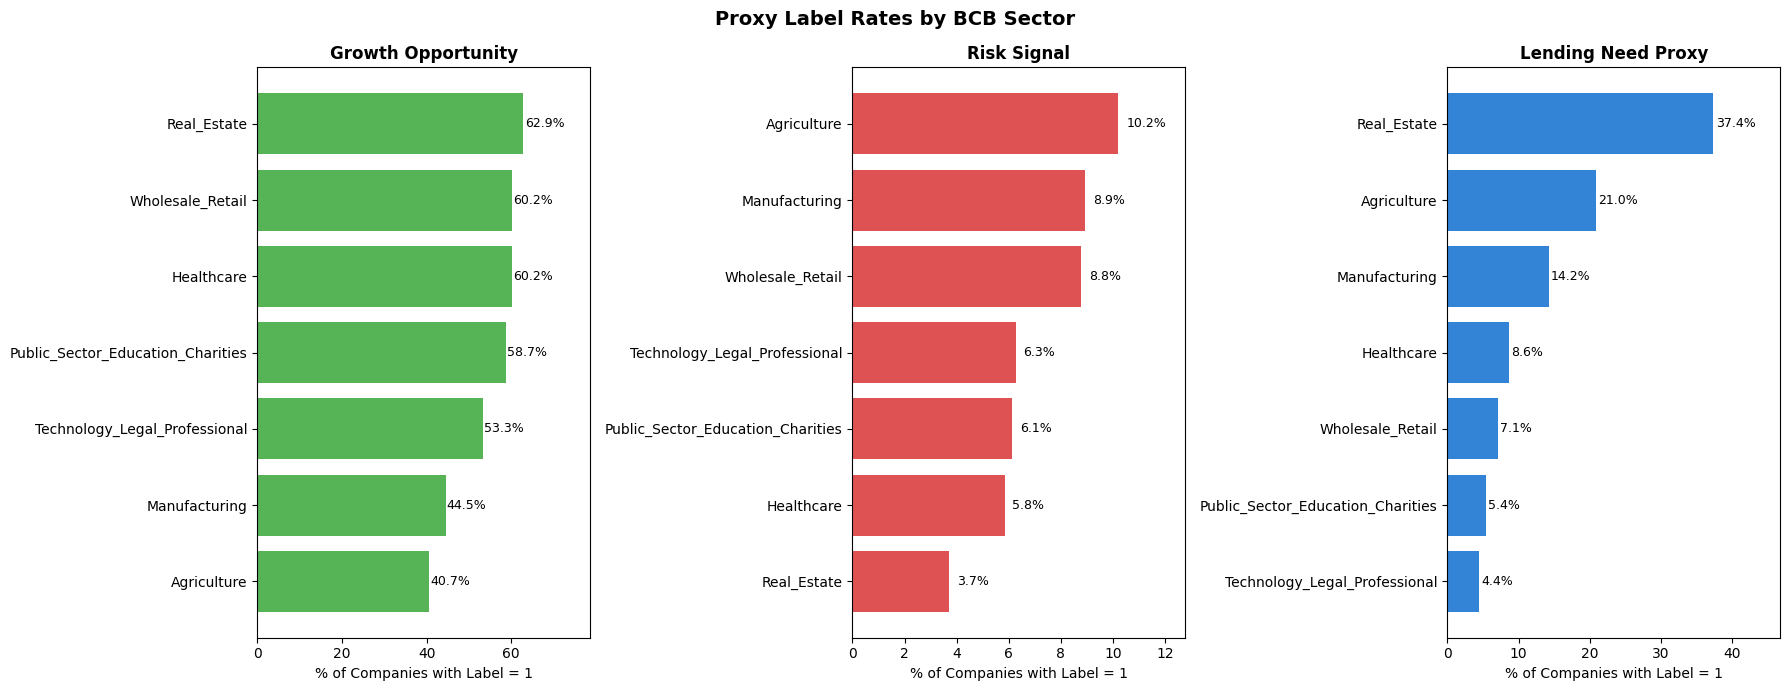

Saved: chart4_labels_by_sector.png

--- Label Rates by Sector (%) ---

label_growth_opportunity:
  Real_Estate                                   62.9%
  Wholesale_Retail                              60.2%
  Healthcare                                    60.2%
  Public_Sector_Education_Charities             58.7%
  Technology_Legal_Professional                 53.3%
  Manufacturing                                 44.5%
  Agriculture                                   40.7%

label_risk_signal:
  Agriculture                                   10.2%
  Manufacturing                                 8.9%
  Wholesale_Retail                              8.8%
  Technology_Legal_Professional                 6.3%
  Public_Sector_Education_Charities             6.1%
  Healthcare                                    5.8%
  Real_Estate                                   3.7%

label_lending_need_proxy:
  Real_Estate                                   37.4%
  Agriculture                                   21.0

In [32]:
# ============================================================
# CHART 4 — LABEL RATES BY SECTOR
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Proxy Label Rates by BCB Sector', fontsize=14, fontweight='bold')

labels = ['label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']
titles = ['Growth Opportunity', 'Risk Signal', 'Lending Need Proxy']
colors = ['#2ca02c', '#d62728', '#0066cc']

for ax, label, title, color in zip(axes, labels, titles, colors):
    sector_rates = df.groupby('bcb_sector')[label].mean().sort_values(ascending=True) * 100
    bars = ax.barh(sector_rates.index, sector_rates.values, color=color, alpha=0.8)
    ax.set_xlabel('% of Companies with Label = 1')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, sector_rates.max() * 1.25)
    for bar, val in zip(bars, sector_rates.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/chart4_labels_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_labels_by_sector.png")

print("\n--- Label Rates by Sector (%) ---")
for label in labels:
    print(f"\n{label}:")
    rates = df.groupby('bcb_sector')[label].mean().sort_values(ascending=False) * 100
    for sector, rate in rates.items():
        print(f"  {sector:<45} {rate:.1f}%")

## Section 6 — Company Health & Filing Behaviour

Four complementary views of company health:

- **Overdue accounts:** Most overdue companies are within 0-100 days late. The spike at 730 days represents companies that are effectively abandoned but not yet dissolved — a data quality consideration
- **Active vs Dormant:** 92% of BCB companies are active. Wholesale/Retail has the highest dormancy rate, inflating raw prospect counts in that sector
- **Account categories:** 1.08M companies are Micro-Entity (turnover under £632k). Many of these may be too small for commercial banking products — a segmentation consideration
- **Mortgage activity:** Real Estate (38.7%) and Agriculture (25.8%) have the highest active mortgage rates, consistent with their high lending need scores

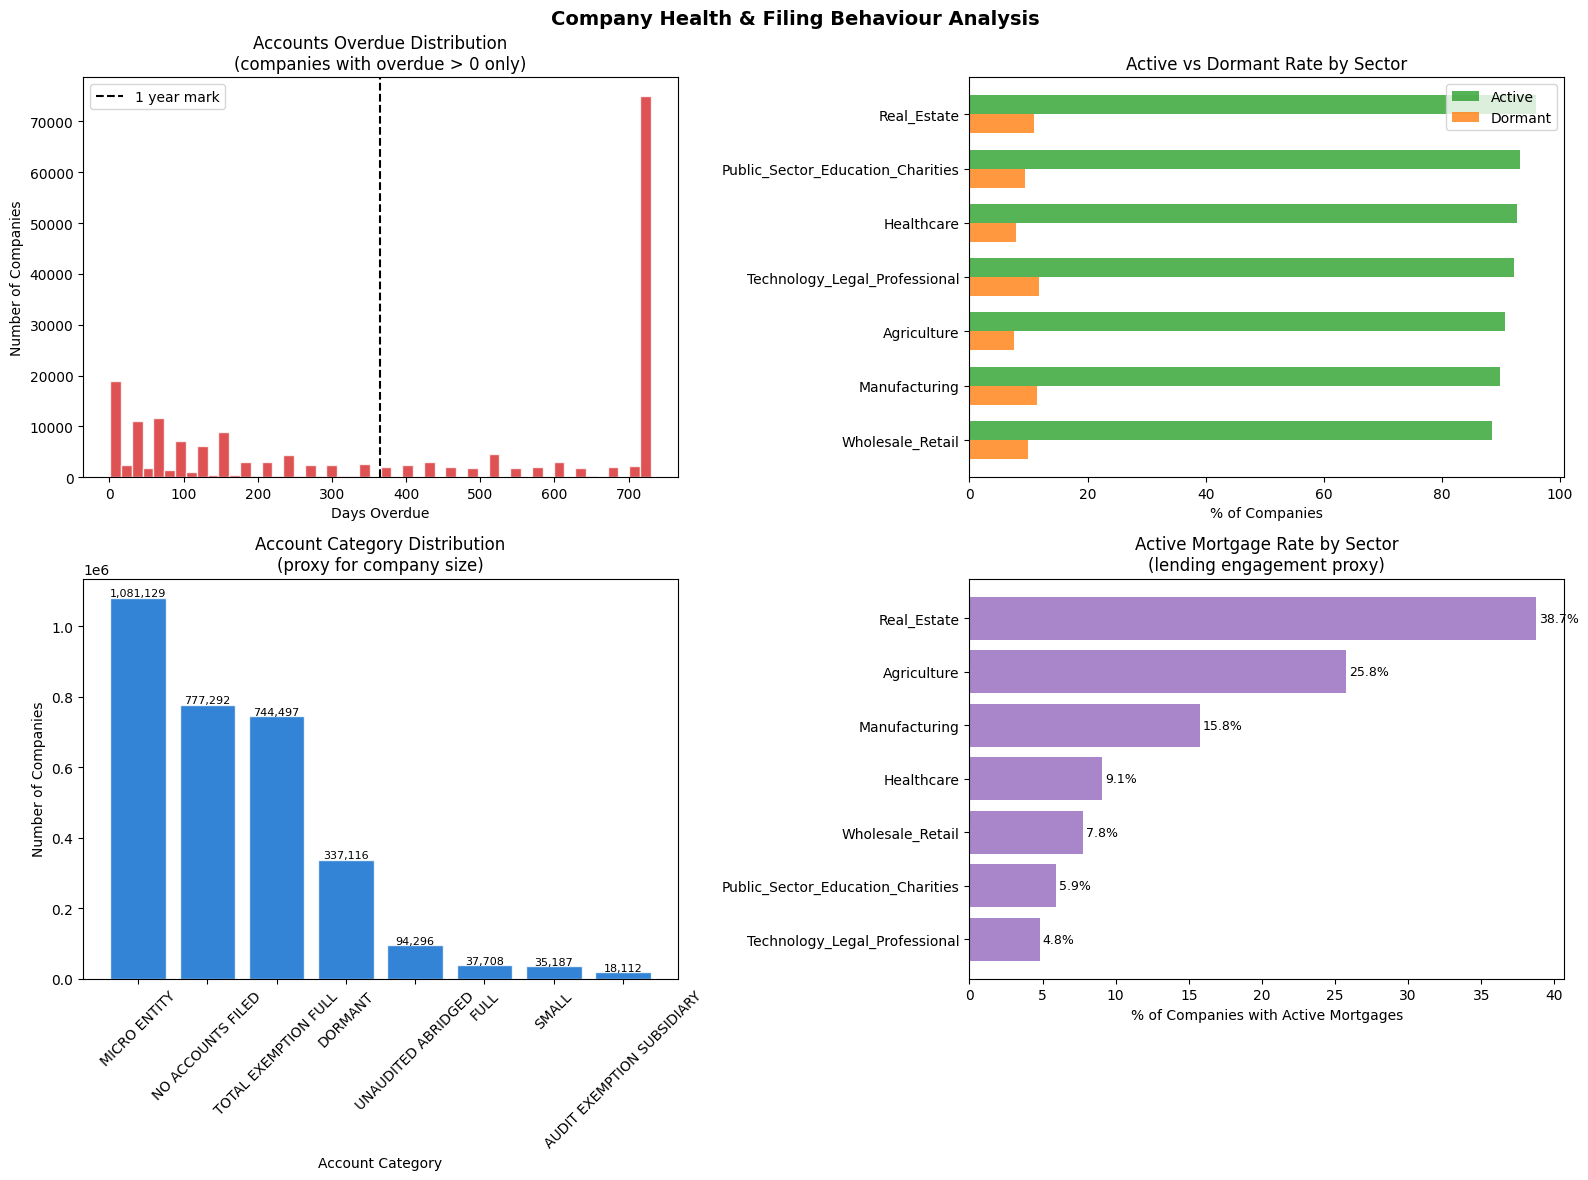

Saved: chart5_company_health.png

--- Key Health Statistics ---
Active companies:      92.0%
Dormant companies:     10.7%
Has active mortgages:  13.7%
Accounts overdue:      6.2%
Ever filed late:       6.2%


In [33]:
# ============================================================
# CHART 5 — COMPANY HEALTH & FILING BEHAVIOUR
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Company Health & Filing Behaviour Analysis', fontsize=14, fontweight='bold')

# 5a — Accounts overdue distribution
overdue_data = df[df['accounts_overdue_days'] > 0]['accounts_overdue_days'].clip(0, 730)
axes[0,0].hist(overdue_data, bins=50, color='#d62728', alpha=0.8, edgecolor='white')
axes[0,0].set_xlabel('Days Overdue')
axes[0,0].set_ylabel('Number of Companies')
axes[0,0].set_title('Accounts Overdue Distribution\n(companies with overdue > 0 only)')
axes[0,0].axvline(365, color='black', linestyle='--', linewidth=1.5, label='1 year mark')
axes[0,0].legend()

# 5b — Active vs Dormant by sector
status_sector = df.groupby('bcb_sector').agg(
    active=('is_active', 'mean'),
    dormant=('is_dormant', 'mean')
).reset_index().sort_values('active', ascending=True)

x = range(len(status_sector))
width = 0.35
axes[0,1].barh([i + width/2 for i in x], status_sector['active']*100,
               width, label='Active', color='#2ca02c', alpha=0.8)
axes[0,1].barh([i - width/2 for i in x], status_sector['dormant']*100,
               width, label='Dormant', color='#ff7f0e', alpha=0.8)
axes[0,1].set_yticks(list(x))
axes[0,1].set_yticklabels(status_sector['bcb_sector'])
axes[0,1].set_xlabel('% of Companies')
axes[0,1].set_title('Active vs Dormant Rate by Sector')
axes[0,1].legend()

# 5c — Account category breakdown
cat_counts = df['account_category'].value_counts().head(8)
axes[1,0].bar(cat_counts.index, cat_counts.values, color='#0066cc', alpha=0.8, edgecolor='white')
axes[1,0].set_xlabel('Account Category')
axes[1,0].set_ylabel('Number of Companies')
axes[1,0].set_title('Account Category Distribution\n(proxy for company size)')
axes[1,0].tick_params(axis='x', rotation=45)
for i, (cat, val) in enumerate(cat_counts.items()):
    axes[1,0].text(i, val + 5000, f'{val:,}', ha='center', fontsize=8)

# 5d — Mortgage activity by sector
mort_sector = df.groupby('bcb_sector')['has_active_mortgages'].mean().sort_values(ascending=True) * 100
bars = axes[1,1].barh(mort_sector.index, mort_sector.values, color='#9467bd', alpha=0.8)
axes[1,1].set_xlabel('% of Companies with Active Mortgages')
axes[1,1].set_title('Active Mortgage Rate by Sector\n(lending engagement proxy)')
for bar, val in zip(bars, mort_sector.values):
    axes[1,1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/chart5_company_health.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart5_company_health.png")

print("\n--- Key Health Statistics ---")
print(f"Active companies:      {df['is_active'].mean()*100:.1f}%")
print(f"Dormant companies:     {df['is_dormant'].mean()*100:.1f}%")
print(f"Has active mortgages:  {df['has_active_mortgages'].mean()*100:.1f}%")
print(f"Accounts overdue:      {(df['accounts_overdue_days'] > 0).mean()*100:.1f}%")
print(f"Ever filed late:       {df['accounts_ever_late'].mean()*100:.1f}%")

## Section 7 — Feature Correlation Heatmap

**Critical finding — Label Leakage:**

Two near-perfect correlations are visible between features and labels:

- `label_risk_signal` ↔ `accounts_ever_late`: **+0.97** correlation
- `label_lending_need_proxy` ↔ `has_active_mortgages`: **+0.96** correlation

These correlations exist because these columns were used to *construct* the labels. If left in the feature set during training, the model will trivially reconstruct the label formula and achieve ~99% accuracy — which is misleading and useless in practice.

**Required action before training:**
- When training `label_risk_signal`: drop `accounts_ever_late`, `conf_stmt_overdue_days`, `accounts_overdue_days`
- When training `label_lending_need_proxy`: drop `has_active_mortgages`, `num_mortgages_outstanding`, `num_mortgages_total`
- When training `label_growth_opportunity`: drop `company_age_years`, `is_active`, `is_dormant`, `accounts_overdue_days`

Features in heatmap: 17
['company_age_years', 'accounts_overdue_days', 'accounts_ever_late', 'conf_stmt_overdue_days', 'num_mortgages_outstanding', 'num_mortgages_total', 'has_active_mortgages', 'has_changed_name', 'is_active', 'is_dormant', 'is_micro', 'is_small', 'is_full_accounts', 'fast_growth_proxy', 'label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']


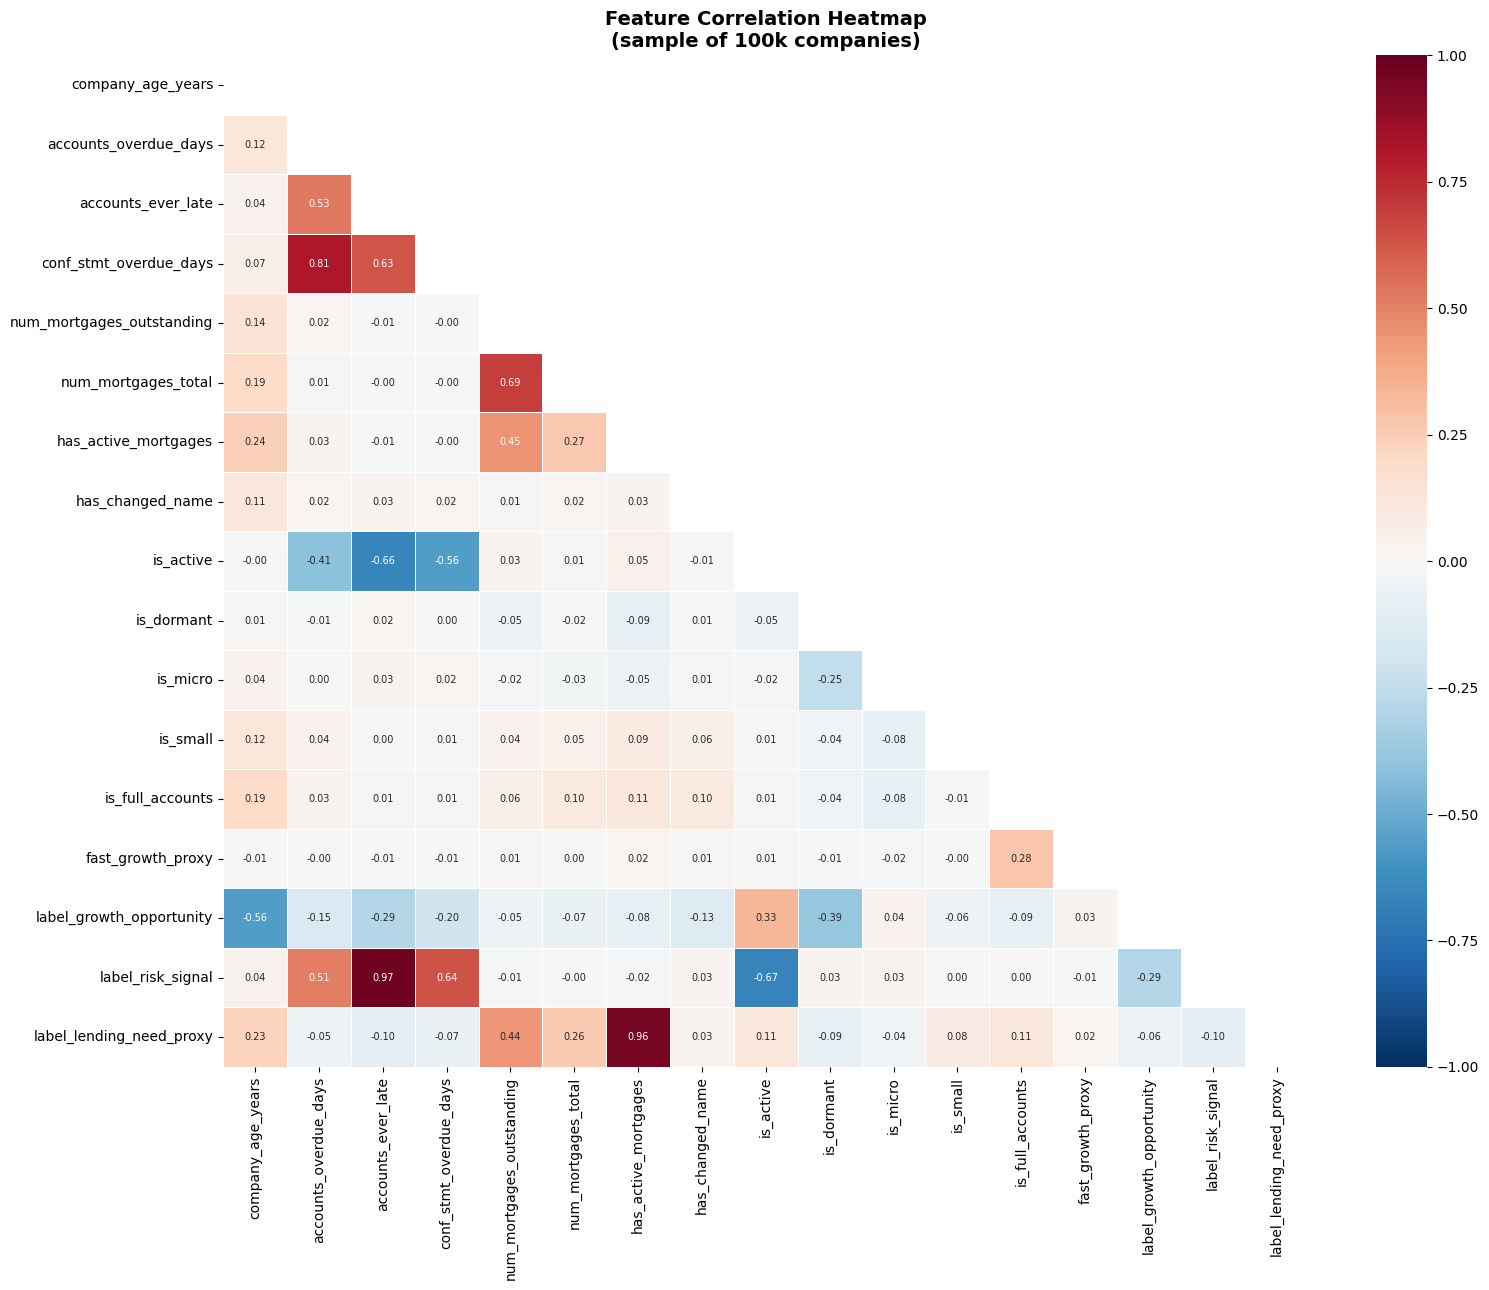

Saved: chart6_correlation_heatmap.png

--- Top Correlations with Each Label ---

label_growth_opportunity:
  company_age_years                   -0.560
  is_dormant                          -0.390
  is_active                           +0.330
  accounts_ever_late                  -0.290
  conf_stmt_overdue_days              -0.200
  accounts_overdue_days               -0.150

label_risk_signal:
  accounts_ever_late                  +0.970
  is_active                           -0.670
  conf_stmt_overdue_days              +0.640
  accounts_overdue_days               +0.510
  company_age_years                   +0.040
  has_changed_name                    +0.030

label_lending_need_proxy:
  has_active_mortgages                +0.960
  num_mortgages_outstanding           +0.440
  num_mortgages_total                 +0.260
  company_age_years                   +0.230
  is_active                           +0.110
  is_full_accounts                    +0.110


In [34]:
# ============================================================
# CHART 6 — FEATURE CORRELATION HEATMAP
# ============================================================

numeric_features = [
    'company_age_years', 'accounts_overdue_days', 'accounts_ever_late',
    'conf_stmt_overdue_days', 'num_mortgages_outstanding', 'num_mortgages_total',
    'has_active_mortgages', 'has_changed_name', 'is_active', 'is_dormant',
    'is_micro', 'is_small', 'is_full_accounts', 'fast_growth_proxy',
    'has_late_filing_history', 'director_turnover_signal', 'director_resignations_1yr',
    'avg_tone', 'pct_negative', 'sector_avg_tone', 'sector_volume_trend',
    'label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy'
]

# Filter to only columns that actually exist in the dataset
numeric_features = [c for c in numeric_features if c in df.columns]
print(f"Features in heatmap: {len(numeric_features)}")
print(numeric_features)

# Sample for performance
sample = df[numeric_features].sample(100000, random_state=42)
corr_matrix = sample.corr().round(2)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, annot_kws={'size': 7}, linewidths=0.5
)
ax.set_title('Feature Correlation Heatmap\n(sample of 100k companies)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/chart6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6_correlation_heatmap.png")

print("\n--- Top Correlations with Each Label ---")
for label in ['label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']:
    print(f"\n{label}:")
    label_corr = corr_matrix[label].drop([
        'label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy'
    ]).sort_values(key=abs, ascending=False)
    for feat, val in label_corr.head(6).items():
        print(f"  {feat:<35} {val:+.3f}")

## Section 8 — Missing Value Analysis

Only two columns have meaningful missingness after Bhavika's cleaning:
- `accounts_last_made_up`: 24.7% missing
- `ConfStmtLastMadeUpDate`: 17.6% missing

**Important finding — missingness is not random (MNAR):**

Companies where `accounts_last_made_up` is missing show a 91.6% growth opportunity rate, compared to only 45.2% for companies where it is present. This is a Missing Not At Random (MNAR) pattern — these companies have likely never filed accounts because they are very newly incorporated. The label logic classifies them as growth opportunities, but they may simply be dormant shells or pre-trading entities.

**Dissertation implication:** This is a genuine limitation of proxy label construction from administrative data. It should be discussed in the methodology limitations section.

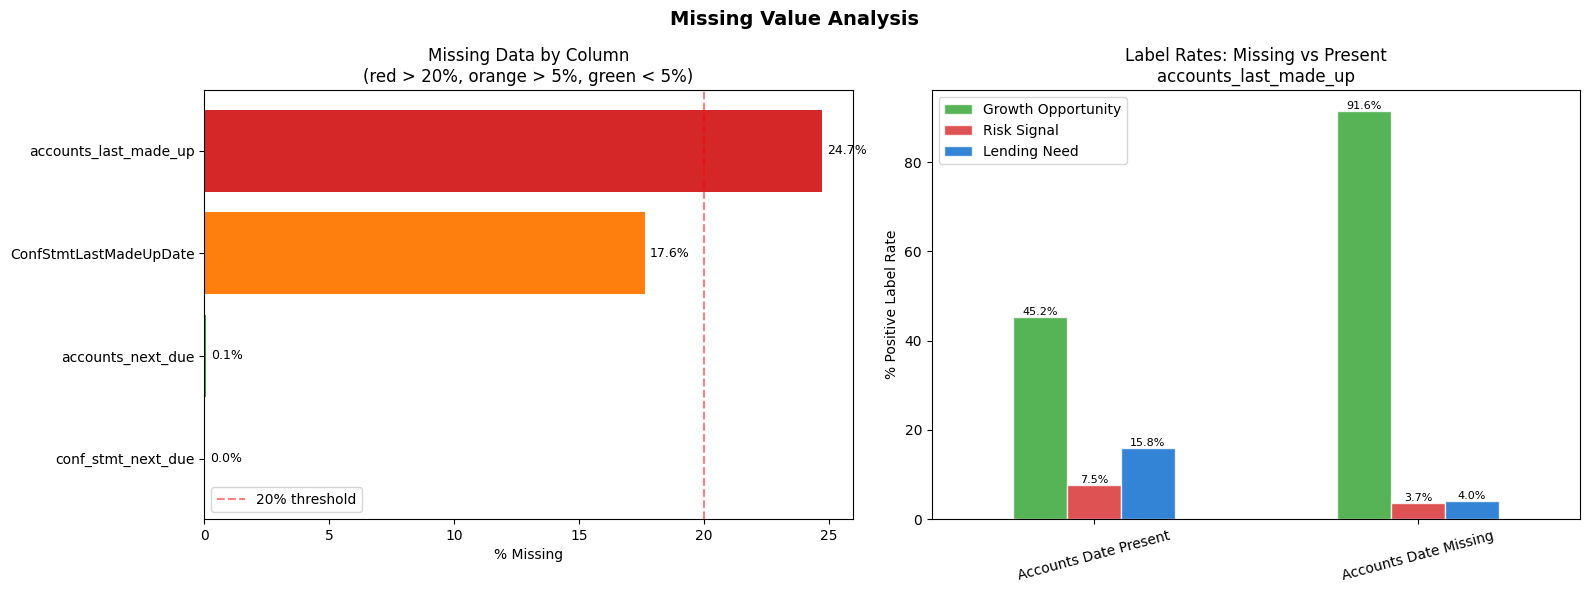

Saved: chart7_missing_values.png

Label rates where accounts date IS missing:
label_growth_opportunity    91.6
label_risk_signal            3.7
label_lending_need_proxy     4.0

Label rates where accounts date IS present:
label_growth_opportunity    45.2
label_risk_signal            7.5
label_lending_need_proxy    15.8


In [35]:
# ============================================================
# CHART 7 — MISSING VALUE ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')

# Left — missing value bar chart
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = missing_pct[missing_pct > 0].sort_values(ascending=True)

colors_missing = ['#d62728' if x > 20 else '#ff7f0e' if x > 5 else '#2ca02c'
                  for x in missing_report.values]
bars = axes[0].barh(missing_report.index, missing_report.values, color=colors_missing)
axes[0].set_xlabel('% Missing')
axes[0].set_title('Missing Data by Column\n(red > 20%, orange > 5%, green < 5%)')
axes[0].axvline(20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
for bar, val in zip(bars, missing_report.values):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
axes[0].legend()

# Right — does missingness correlate with labels?
df['accounts_missing'] = df['accounts_last_made_up'].isnull().astype(int)
missing_label_rates = df.groupby('accounts_missing')[
    ['label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']
].mean() * 100
missing_label_rates.index = ['Accounts Date Present', 'Accounts Date Missing']

missing_label_rates.plot(kind='bar', ax=axes[1],
                         color=['#2ca02c', '#d62728', '#0066cc'], alpha=0.8, edgecolor='white')
axes[1].set_xlabel('')
axes[1].set_ylabel('% Positive Label Rate')
axes[1].set_title('Label Rates: Missing vs Present\naccounts_last_made_up')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Growth Opportunity', 'Risk Signal', 'Lending Need'])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.savefig('output/chart7_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart7_missing_values.png")

print(f"\nLabel rates where accounts date IS missing:")
print(missing_label_rates.loc['Accounts Date Missing'].round(1).to_string())
print(f"\nLabel rates where accounts date IS present:")
print(missing_label_rates.loc['Accounts Date Present'].round(1).to_string())

## Section 9 — Label Rates by Company Age Band

Breaking company age into discrete bands reveals distinct patterns for each label:

- **Growth Opportunity** drops to exactly 0% for companies over 10 years old — a direct consequence of the label definition which caps at 10 years. This confirms age is the dominant feature and should be noted as a design constraint
- **Risk Signal** peaks in the 5-10 year band (12.7%), not the youngest band — mid-age companies have had time to accumulate late filings and director turnover, making them the highest-risk cohort
- **Lending Need** increases steadily with age, peaking at 45.6% for 50+ year companies — established businesses borrow more, which is commercially intuitive and validates the label construction

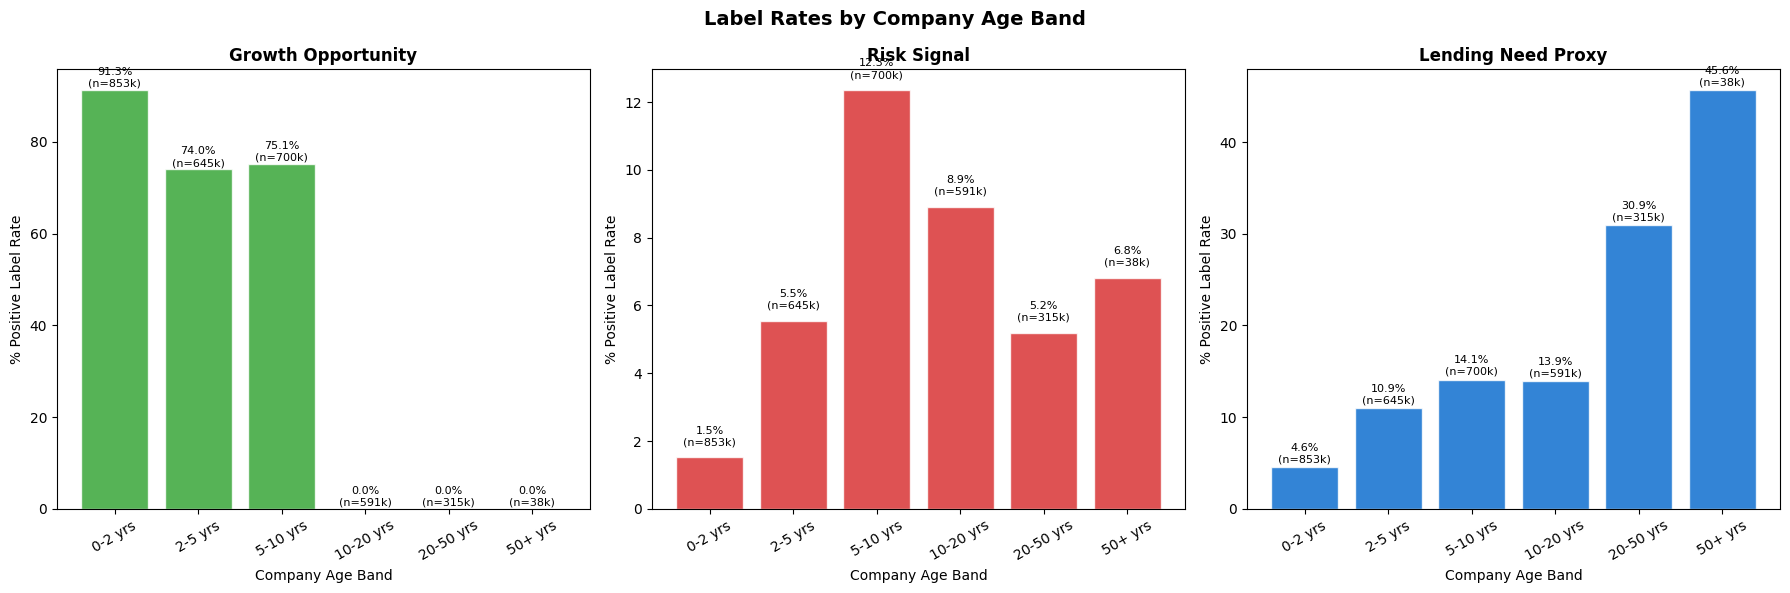

Saved: chart8_age_bands_vs_labels.png


In [36]:
# ============================================================
# CHART 8 — LABEL RATES BY COMPANY AGE BAND
# ============================================================

df['age_band'] = pd.cut(df['company_age_years'],
                         bins=[0, 2, 5, 10, 20, 50, 200],
                         labels=['0-2 yrs', '2-5 yrs', '5-10 yrs',
                                 '10-20 yrs', '20-50 yrs', '50+ yrs'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Label Rates by Company Age Band', fontsize=14, fontweight='bold')

labels_info = [
    ('label_growth_opportunity', 'Growth Opportunity', '#2ca02c'),
    ('label_risk_signal',        'Risk Signal',        '#d62728'),
    ('label_lending_need_proxy', 'Lending Need Proxy', '#0066cc'),
]

for ax, (label, title, color) in zip(axes, labels_info):
    age_rates = df.groupby('age_band', observed=True)[label].agg(['mean', 'count'])
    age_rates['mean_pct'] = age_rates['mean'] * 100
    bars = ax.bar(age_rates.index, age_rates['mean_pct'], color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Company Age Band')
    ax.set_ylabel('% Positive Label Rate')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for bar, (_, row) in zip(bars, age_rates.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{row['mean_pct']:.1f}%\n(n={row['count']//1000:.0f}k)",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('output/chart8_age_bands_vs_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart8_age_bands_vs_labels.png")

=== GDELT COLUMN AUDIT ===
Columns present in dataset: []
Columns NOT in dataset:     ['avg_tone', 'pct_negative', 'sector_avg_tone', 'sector_volume_trend']

All GDELT columns were removed during cleaning (all were 100% null).
This confirms GDELT returned no usable data for this dataset.
Dissertation note: labels were rebuilt using Companies House structured
data only because GDELT returned zero articles for all sampled companies.


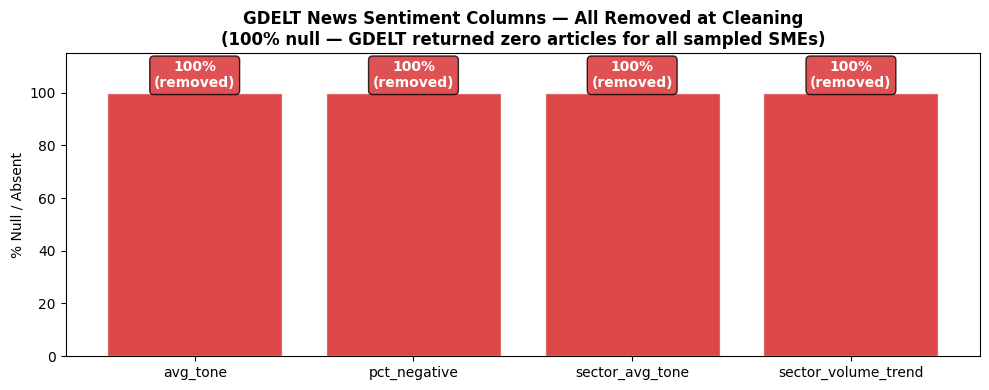

Saved: chart9_gdelt_null_analysis.png


In [37]:
# ============================================================
# CHART 9 — GDELT NEWS FEATURES: NULL ANALYSIS
# This justifies why labels were rebuilt from Companies House
# data only, without news sentiment
# ============================================================

gdelt_cols = ['avg_tone', 'pct_negative', 'sector_avg_tone', 'sector_volume_trend']

# Check which ones exist in the dataset
existing_gdelt = [c for c in gdelt_cols if c in df.columns]
missing_gdelt  = [c for c in gdelt_cols if c not in df.columns]

print("=== GDELT COLUMN AUDIT ===")
print(f"Columns present in dataset: {existing_gdelt}")
print(f"Columns NOT in dataset:     {missing_gdelt}")

if existing_gdelt:
    print("\n--- Null rates for present GDELT columns ---")
    for col in existing_gdelt:
        null_pct = df[col].isnull().mean() * 100
        non_null = df[col].notna().sum()
        print(f"  {col:<30} {null_pct:.1f}% null  ({non_null:,} non-null values)")

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 4))
    null_rates = {col: df[col].isnull().mean() * 100 for col in existing_gdelt}
    colors = ['#d62728' if v > 80 else '#ff7f0e' for v in null_rates.values()]
    bars = ax.bar(null_rates.keys(), null_rates.values(), color=colors, alpha=0.85, edgecolor='white')
    ax.set_ylabel('% Null Values')
    ax.set_ylim(0, 105)
    ax.set_title('GDELT News Sentiment Columns — Null Rate\n'
                 'Justification for rebuilding labels from Companies House data only',
                 fontweight='bold')
    ax.axhline(80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
    ax.legend()
    for bar, val in zip(bars, null_rates.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/chart9_gdelt_null_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: chart9_gdelt_null_analysis.png")
else:
    print("\nAll GDELT columns were removed during cleaning (all were 100% null).")
    print("This confirms GDELT returned no usable data for this dataset.")
    print("Dissertation note: labels were rebuilt using Companies House structured")
    print("data only because GDELT returned zero articles for all sampled companies.")

    # Still create a visual showing this finding clearly
    fig, ax = plt.subplots(figsize=(10, 4))
    gdelt_expected = ['avg_tone', 'pct_negative', 'sector_avg_tone', 'sector_volume_trend']
    ax.bar(gdelt_expected, [100, 100, 100, 100], color='#d62728', alpha=0.85, edgecolor='white')
    ax.set_ylabel('% Null / Absent')
    ax.set_ylim(0, 115)
    ax.set_title('GDELT News Sentiment Columns — All Removed at Cleaning\n'
                 '(100% null — GDELT returned zero articles for all sampled SMEs)',
                 fontweight='bold')
    for i, col in enumerate(gdelt_expected):
        ax.text(i, 102, '100%\n(removed)', ha='center', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round', facecolor='#d62728', alpha=0.8))
    plt.tight_layout()
    plt.savefig('output/chart9_gdelt_null_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: chart9_gdelt_null_analysis.png")

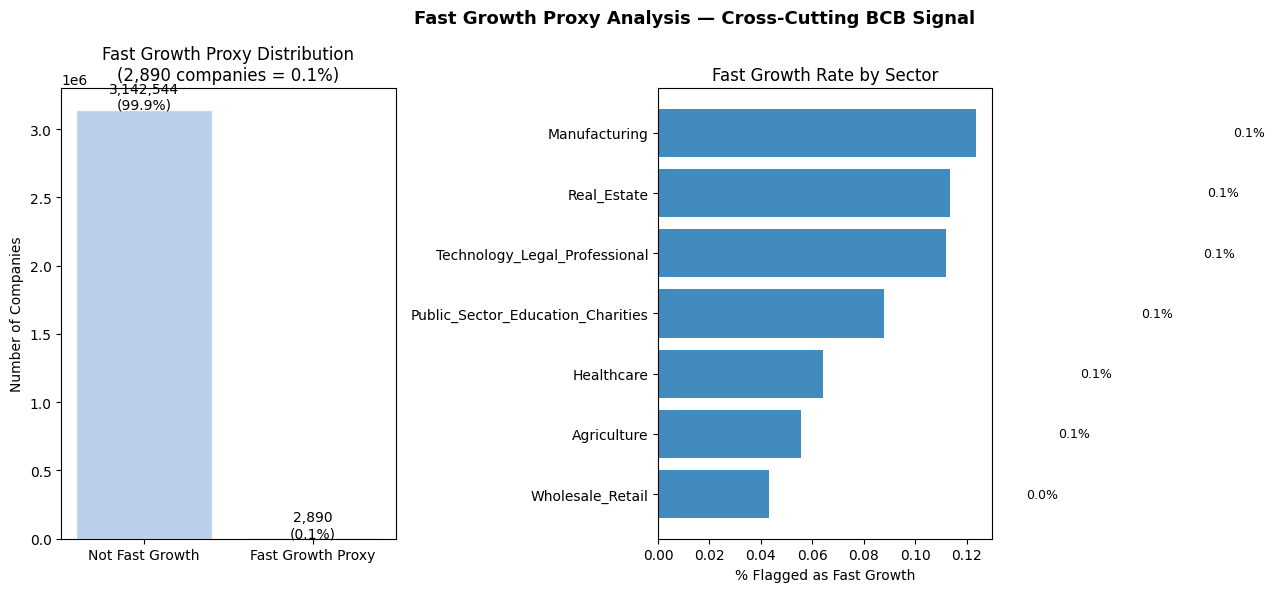

Saved: chart10_fast_growth_proxy.png

--- Fast Growth Proxy Summary ---
Total flagged: 2,890 (0.1% of all BCB companies)

By sector:
  Manufacturing                                 0.1%  (293 companies)
  Real_Estate                                   0.1%  (710 companies)
  Technology_Legal_Professional                 0.1%  (1,276 companies)
  Public_Sector_Education_Charities             0.1%  (133 companies)
  Healthcare                                    0.1%  (130 companies)
  Agriculture                                   0.1%  (26 companies)
  Wholesale_Retail                              0.0%  (322 companies)


In [38]:
# ============================================================
# CHART 10 — FAST GROWTH PROXY ANALYSIS
# fast_growth_proxy is a cross-cutting BCB sector signal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fast Growth Proxy Analysis — Cross-Cutting BCB Signal', 
             fontsize=13, fontweight='bold')

# Left — overall rate
total_flagged = df['fast_growth_proxy'].sum()
total_pct = total_flagged / len(df) * 100
axes[0].bar(['Not Fast Growth', 'Fast Growth Proxy'],
            [len(df) - total_flagged, total_flagged],
            color=['#aec7e8', '#1f77b4'], alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Number of Companies')
axes[0].set_title(f'Fast Growth Proxy Distribution\n({total_flagged:,} companies = {total_pct:.1f}%)')
for i, val in enumerate([len(df) - total_flagged, total_flagged]):
    pct = val / len(df) * 100
    axes[0].text(i, val + 5000, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)

# Right — fast growth rate by sector
fg_by_sector = df.groupby('bcb_sector')['fast_growth_proxy'].mean().sort_values(ascending=True) * 100
bars = axes[1].barh(fg_by_sector.index, fg_by_sector.values, color='#1f77b4', alpha=0.85)
axes[1].set_xlabel('% Flagged as Fast Growth')
axes[1].set_title('Fast Growth Rate by Sector')
for bar, val in zip(bars, fg_by_sector.values):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/chart10_fast_growth_proxy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart10_fast_growth_proxy.png")

print(f"\n--- Fast Growth Proxy Summary ---")
print(f"Total flagged: {total_flagged:,} ({total_pct:.1f}% of all BCB companies)")
print(f"\nBy sector:")
for sector, rate in fg_by_sector.sort_values(ascending=False).items():
    count = df[df['bcb_sector'] == sector]['fast_growth_proxy'].sum()
    print(f"  {sector:<45} {rate:.1f}%  ({count:,} companies)")

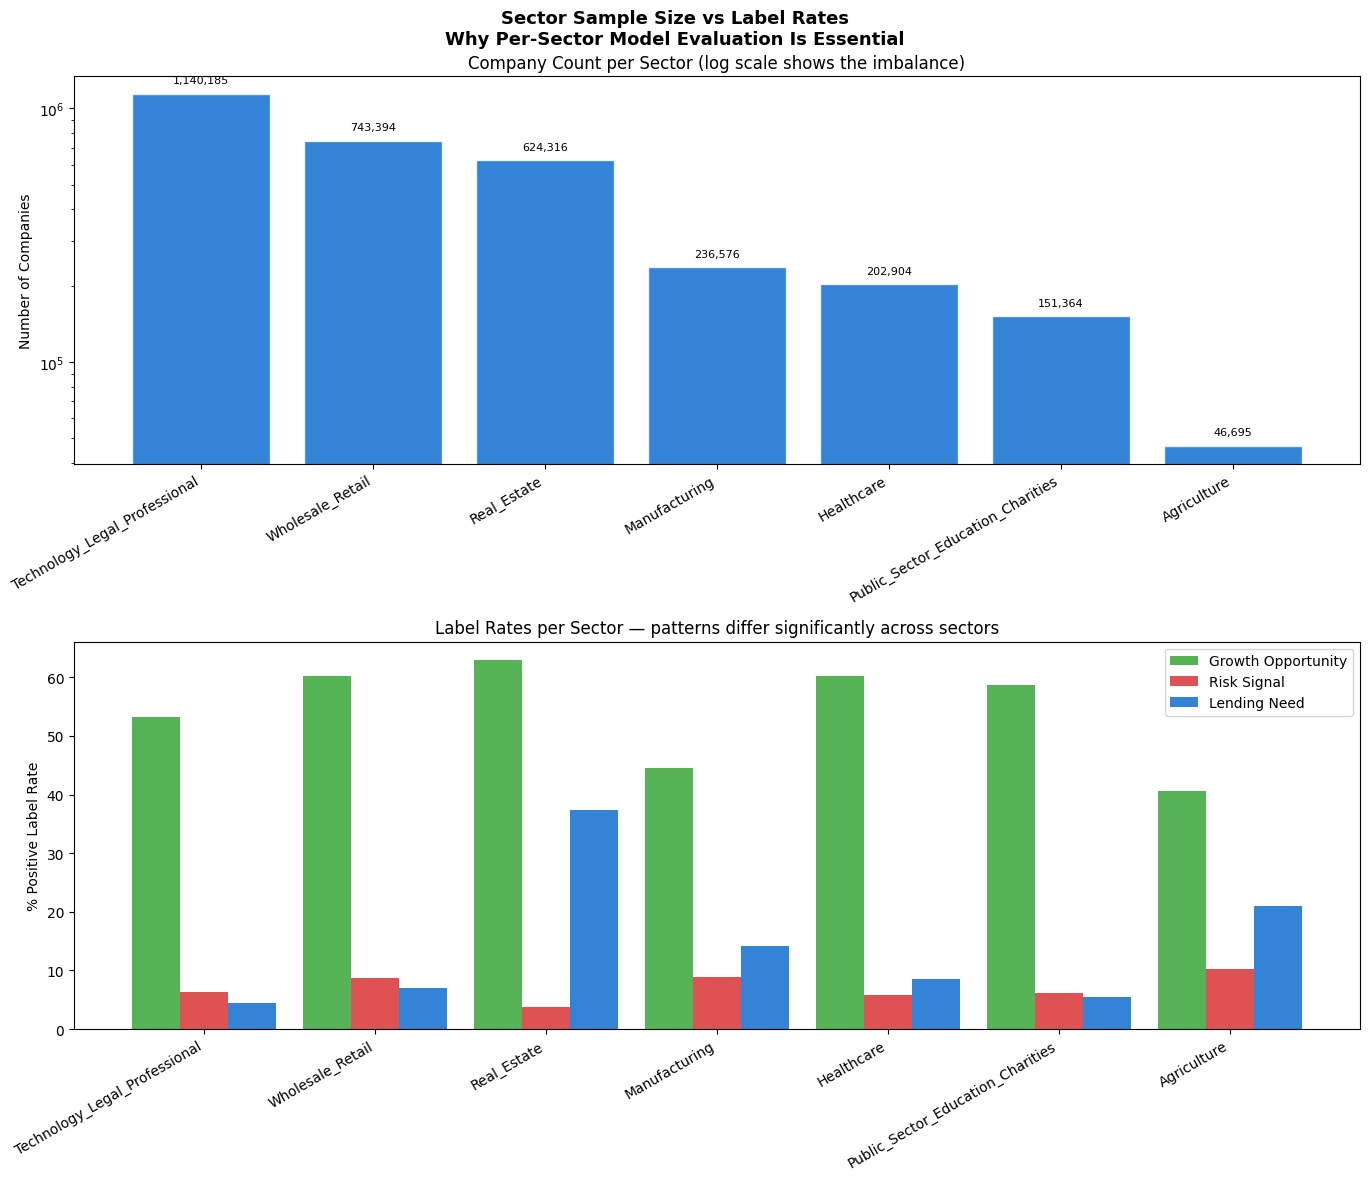

Saved: chart11_sector_size_vs_labels.png

--- Sector Summary Table ---
Sector                                             Count   Growth%   Risk%   Lending%
-------------------------------------------------------------------------------------
Technology_Legal_Professional                  1,140,185     53.3%    6.3%       4.4%
Wholesale_Retail                                 743,394     60.2%    8.8%       7.1%
Real_Estate                                      624,316     62.9%    3.7%      37.4%
Manufacturing                                    236,576     44.5%    8.9%      14.2%
Healthcare                                       202,904     60.2%    5.8%       8.6%
Public_Sector_Education_Charities                151,364     58.7%    6.1%       5.4%
Agriculture                                       46,695     40.7%   10.2%      21.0%


In [39]:
# ============================================================
# CHART 11 — SECTOR SAMPLE SIZE vs LABEL RATES
# Shows why per-sector evaluation is essential —
# Tech/Legal has 24x more companies than Agriculture
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Sector Sample Size vs Label Rates\nWhy Per-Sector Model Evaluation Is Essential',
             fontsize=13, fontweight='bold')

sector_summary = df.groupby('bcb_sector').agg(
    count=('CompanyNumber', 'count'),
    growth_rate=('label_growth_opportunity', 'mean'),
    risk_rate=('label_risk_signal', 'mean'),
    lending_rate=('label_lending_need_proxy', 'mean')
).reset_index().sort_values('count', ascending=False)

sectors = sector_summary['bcb_sector']
x = range(len(sectors))

# Top — sample sizes
bars = axes[0].bar(x, sector_summary['count'], color='#0066cc', alpha=0.8, edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(sectors, rotation=30, ha='right')
axes[0].set_ylabel('Number of Companies')
axes[0].set_title('Company Count per Sector (log scale shows the imbalance)')
axes[0].set_yscale('log')
for bar, val in zip(bars, sector_summary['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{val:,}', ha='center', fontsize=8, rotation=0)

# Bottom — label rates side by side
width = 0.28
axes[1].bar([i - width for i in x], sector_summary['growth_rate']*100,
            width, label='Growth Opportunity', color='#2ca02c', alpha=0.8)
axes[1].bar([i        for i in x], sector_summary['risk_rate']*100,
            width, label='Risk Signal',        color='#d62728', alpha=0.8)
axes[1].bar([i + width for i in x], sector_summary['lending_rate']*100,
            width, label='Lending Need',       color='#0066cc', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(sectors, rotation=30, ha='right')
axes[1].set_ylabel('% Positive Label Rate')
axes[1].set_title('Label Rates per Sector — patterns differ significantly across sectors')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/chart11_sector_size_vs_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart11_sector_size_vs_labels.png")

print("\n--- Sector Summary Table ---")
print(f"{'Sector':<45} {'Count':>10} {'Growth%':>9} {'Risk%':>7} {'Lending%':>10}")
print("-" * 85)
for _, row in sector_summary.iterrows():
    print(f"{row['bcb_sector']:<45} {row['count']:>10,} "
          f"{row['growth_rate']*100:>8.1f}% "
          f"{row['risk_rate']*100:>6.1f}% "
          f"{row['lending_rate']*100:>9.1f}%")

In [40]:
# ============================================================
# CLEANUP — Drop temporary columns added during EDA
# ============================================================

cols_to_drop = [c for c in ['accounts_missing', 'age_band'] if c in df.columns]
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"Cleaned up temporary columns: {cols_to_drop}")
else:
    print("No temporary columns to clean up.")

print(f"Final dataframe shape: {df.shape}")

Cleaned up temporary columns: ['accounts_missing', 'age_band']
Final dataframe shape: (3145434, 40)


## Section 10 — Key Findings Summary

This section consolidates all EDA findings into a structured reference for the dissertation and modelling team.

In [41]:
# ============================================================
# Complete reference for dissertation and modelling team
# ============================================================

print("=" * 62)
print("EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 62)
print("""
1. DATASET SCALE
   - 3.14M companies across 7 BCB sectors, 40 clean features
   - Memory: 3.83GB | Cleaned from 110 raw columns by Bhavika

2. SECTOR DISTRIBUTION
   - Tech/Legal dominates: 36.2% (1.14M companies)
   - Agriculture smallest: 1.5% (47K companies)
   - 24x size difference between largest and smallest sector
   - Action: evaluate models per-sector, not just overall accuracy

3. LABEL DISTRIBUTIONS & CLASS IMBALANCE
   - Growth Opportunity: 56.7% positive — balanced, easy to model
   - Risk Signal:        6.6%  positive — severely imbalanced (14:1)
   - Lending Need:       12.9% positive — moderately imbalanced (7:1)
   - Action: set scale_pos_weight=14 for Risk, =7 for Lending in XGBoost

4. COMPANY AGE
   - Median 5.4 years | 47.6% under 5 years old
   - Growth label concentrated in 0-10 year companies (drops to 0% after)
   - Risk signal peaks at 5-10 years — mid-age companies most at risk
   - Lending need rises steadily with age — peaks at 45.6% for 50+ years

5. LABEL RATES BY SECTOR
   - Real Estate: highest growth (62.9%) AND lending need (37.4%)
   - Agriculture: highest risk signal (10.2%)
   - Tech/Legal: lowest lending need (4.4%) despite being largest sector
   - Real Estate: lowest risk signal (3.7%)

6. LABEL LEAKAGE — CRITICAL WARNING FOR MODELLING

   When training label_growth_opportunity — DROP these features:
     - company_age_years
     - is_active
     - is_dormant
     - accounts_overdue_days

   When training label_risk_signal — DROP these features:
     - accounts_ever_late
     - has_late_filing_history
     - director_turnover_signal
     - conf_stmt_overdue_days
     - accounts_overdue_days

   When training label_lending_need_proxy — DROP these features:
     - has_active_mortgages
     - num_mortgages_outstanding
     - num_mortgages_total
     - label_risk_signal  (inter-label leakage)

7. GDELT NEWS DATA — COMPLETELY ABSENT
   - avg_tone, pct_negative, sector_avg_tone, sector_volume_trend
     were all 100% null and removed during Bhavika's cleaning step
   - GDELT returned zero articles for all sampled UK SMEs
   - Small private UK companies do not appear in global news databases
   - This is why labels were rebuilt from Companies House data only
   - Dissertation limitation: no media sentiment signal available

8. FAST GROWTH PROXY
   - Cross-cutting signal identifying young, active, compliant companies
   - Rate varies significantly by sector — see Chart 10
   - Can be used as an additional feature in the growth opportunity model

9. MISSING DATA IS NOT RANDOM (MNAR)
   - accounts_last_made_up: 24.7% missing
   - Missing companies show 91.6% growth rate vs 45.2% for present
   - Likely newly incorporated shells with no filing history yet
   - Dissertation limitation: proxy labels may over-classify new shells

10. MORTGAGE & HEALTH SIGNALS
    - Real Estate: 38.7% active mortgages | Agriculture: 25.8%
    - 92% of BCB companies are active | 10.7% dormant
    - 1.08M Micro-Entity companies may be below BCB product threshold
    - Wholesale/Retail has highest dormancy — inflates raw prospect counts
""")

print("=" * 62)
print("Charts saved to output/:")
charts = [
    "chart1_sector_distribution.png",
    "chart2_label_distributions.png",
    "chart3_company_age.png",
    "chart4_labels_by_sector.png",
    "chart5_company_health.png",
    "chart6_correlation_heatmap.png",
    "chart7_missing_values.png",
    "chart8_age_bands_vs_labels.png",
    "chart9_gdelt_null_analysis.png",
    "chart10_fast_growth_proxy.png",
    "chart11_sector_size_vs_labels.png",
]
for c in charts:
    print(f"  - {c}")
print("=" * 62)

EDA COMPLETE — KEY FINDINGS SUMMARY

1. DATASET SCALE
   - 3.14M companies across 7 BCB sectors, 40 clean features
   - Memory: 3.83GB | Cleaned from 110 raw columns by Bhavika

2. SECTOR DISTRIBUTION
   - Tech/Legal dominates: 36.2% (1.14M companies)
   - Agriculture smallest: 1.5% (47K companies)
   - 24x size difference between largest and smallest sector
   - Action: evaluate models per-sector, not just overall accuracy

3. LABEL DISTRIBUTIONS & CLASS IMBALANCE
   - Growth Opportunity: 56.7% positive — balanced, easy to model
   - Risk Signal:        6.6%  positive — severely imbalanced (14:1)
   - Lending Need:       12.9% positive — moderately imbalanced (7:1)
   - Action: set scale_pos_weight=14 for Risk, =7 for Lending in XGBoost

4. COMPANY AGE
   - Median 5.4 years | 47.6% under 5 years old
   - Growth label concentrated in 0-10 year companies (drops to 0% after)
   - Risk signal peaks at 5-10 years — mid-age companies most at risk
   - Lending need rises steadily with age — 